Copyright Matlantis Corp. as contributors to Matlantis contrib project

# Free Energy Calculation Using the MBAR Method

In umbrella sampling, data was collected across regions including normally inaccessible unstable areas by adding artificial potentials (harmonic oscillators) to the system.
In this notebook, the MBAR (Multistate Bennett Acceptance Ratio) method is used to remove the artificial bias from the sampled trajectories and calculate the correct free energy profile (PMF: Potential of Mean Force).

## Step 0-1. Library Installation and Import
Use the pymbar library for convenient access to the MBAR method.

In [1]:
# Install pymbar package if needed
#! pip install pymbar

In [2]:
# Reference
#   https://weitsehsu.com/course/enhanced_sampling/us/
#   https://github.com/choderalab/pymbar-examples/blob/master/umbrella-sampling-pmf/umbrella-sampling.py

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import pymbar
from pymbar import timeseries 

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



## Step 0-2. Check Distribution Overlap

For accurate free energy calculations, the histograms of adjacent windows must sufficiently overlap along the reaction coordinate. If the overlap is insufficient, errors may occur during analysis or the calculation may not converge. If the overlap is insufficient, either weaken the spring constant `KAPPA` or add new windows in between.

In [ ]:
# Load PLUMED Trajectory

data = []
for cv_at in np.linspace(10.2, 18.0, 40):
    data.append(np.loadtxt(f"./output/04_umbrella_sampling/cv_at_{cv_at:.2f}/COLVAR_{cv_at:.2f}")[:, 1])

data = np.array(data)
data.shape

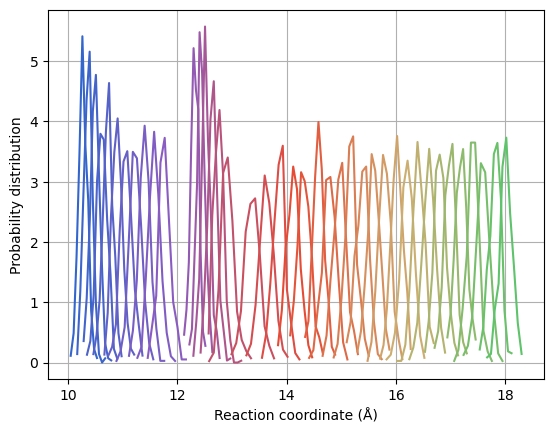

In [4]:
# Gradual color change (blue -> purple -> red -> ochre -> green)
stops = [
    (0.00, "#3366CC"),  # blue
    (0.25, "#8A5CC2"),  # purple
    (0.50, "#E64B35"),  # red
    (0.75, "#CDAE70"),  # orange
    (1.00, "#52C569"),  # green
]
cmap = LinearSegmentedColormap.from_list("blue-red-green", stops)

n_bins = data.shape[0]
for i, dat in enumerate(data):
    hist, bins = np.histogram(dat, bins=10, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    plt.plot(bin_centers, hist, linestyle='solid', label=str(i), color=cmap(i/n_bins), alpha=1.0)

plt.xlabel('Reaction coordinate (Å)')
plt.ylabel('Probability distribution')
plt.grid()
plt.show()

## Step 1. Set Constants

Define the temperature and Boltzmann constant used in the simulation. In MBAR calculations, energy is handled in $k_B T$ units (dimensionless energy), so the inverse temperature $\beta = 1 / k_B T$ is computed.

In [5]:
# Step1: Settings 
kB = 8.617333262e-5  # Boltzmann constant in eV/K
T  = 375.0           # assume a single temperature (in Kelvin)
beta = 1 / (kB * T)

## Step 2. Load Data
Load the following data from each window (z_at) directory:

- `COLVAR`: Time series data of the reaction coordinate (distance)
- `md-dyn.log`: Time series data of the potential energy

The loaded data is stored in lists for MBAR calculation.

In [ ]:
# ============================================================
# 2. Load Trajectory Data
# ============================================================
z_data = [] # Reaction Coordinate
w_data = [] # Bias Potential Energy
U_data = [] # Potential Energy without Bias
u_data = [] # Reduced Potential

beta_k = [] # Inverse temperature for each window
z0_k   = [] # Restraint center position for each window
K_k    = [] # Spring constant for each window

# Window range settings (same range as simulation)
z_min_scan = 10.2
z_max_scan = 18.0
z_step     = 0.2
n_windows  = int(round((z_max_scan - z_min_scan) / z_step)) + 1

print("Loading data...")

# kappa = 2.5 eV
for z_at in np.linspace(z_min_scan, z_max_scan, n_windows):
    # Load trajectory
    path_data = f"./output/04_umbrella_sampling/cv_at_{z_at:.2f}"
    us_data   = np.loadtxt(f"{path_data}/COLVAR_{z_at:.2f}")
    pot_data  = np.loadtxt(f"{path_data}/md-dyn.log", skiprows=1)[:, 2]  # potential energy

    K_k.append(2.5)
    z0_k.append(z_at)
    beta_k.append(beta)
    
    z_data.append(us_data[1:, 1])  # reaction coordinate
    w_data.append(us_data[1:, 2])  # bias potentia.
    U_data.append(pot_data)
    u_data.append(pot_data * beta) # reduced potential for system

# Convert to arrays
K_k    = np.array(K_k)
z0_k   = np.array(z0_k)
beta_k = np.array(beta_k)

z_data = np.array(z_data)
w_data = np.array(w_data)
U_data = np.array(U_data)
u_data = np.array(u_data)

K_k.shape, z0_k.shape, beta_k.shape, z_data.shape, w_data.shape, w_data.shape, U_data.shape, u_data.shape

In [7]:
K_k

array([2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5,
       2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5,
       2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5])

## Step 3. Data Preprocessing (Subsampling)

MD simulation data has time series correlations (each structure is similar to the previous one), so they cannot be considered independent samples. Using pymbar.timeseries, the "statistical inefficiency" is calculated and correlated data is thinned out to extract only highly independent data. This is an important process for accurate error estimation.

In [8]:
# Parameters for CV
K      = K_k.shape[0]    # number of umbrellas
N_max  = z_data.shape[1] # maximum number of snapshots/simulation
z_min  = 10.0            # minimum of the CV for plotting the FES
z_max  = 18.0            # maximum of the CV for plotting the FES
nbins  =   40            # number of bins for 1D PMF

# Allocate storage for simulation data
N_k    = np.zeros([K], np.int32)          # N_k[k] is the number of snapshots from umbrella simulation k
g_k    = np.zeros([K], np.float32)        # g_k[k] is the statistical inefficiency of umbrella simulation k
z_kn   = np.zeros([K, N_max], np.float64) # z_kn[k,n] is the pulled atom position (in Angstrom) for snapshot n from umbrella simulation k
W_kn   = np.zeros([K, N_max], np.float64) # W_kn[k,n] is the umbrella potential energy for snapshot n from umbrella simulation k
U_kn   = np.zeros([K, N_max], np.float64) # U_kn[k,n] is the potential energy without umbrella restraints
u_kn   = np.zeros([K, N_max], np.float64) # u_kn[k,n] is the reduced potential energy for snapshot n from umbrella simulation k

In [9]:
# Set data for MBAR analysis
for k in range(K):

    z_full = z_data[k, :]   # reaction coordinates
    W_full = w_data[k, :]   # bias energy
    U_full = U_data[k, :]   # potential energy
    u_full = u_data[k, :]   # reduced potential energy


    # Subsampling
    g_k[k]  = timeseries.statistical_inefficiency(z_full)
    indices = timeseries.subsample_correlated_data(z_full, g=g_k[k])
    N_k[k]  = len(indices)

    U_kn[k, :N_k[k]] = U_full[indices]
    u_kn[k, :N_k[k]] = u_full[indices]
    z_kn[k, :N_k[k]] = z_full[indices]
    W_kn[k, :N_k[k]] = W_full[indices]

## Step 4. Compute Reduced Potential Matrix

Calculate the energy that a structure $n$ obtained in window $k$ would have if it were under the conditions of a different window $l$ (Reduced Potential $u_{k,l,n}$).
This enables probability weighting across different biases.

$$u_{k,l,n} = \beta [ U(x_{kn}) + V_l(x_{kn}) ]$$

where $V_l$ is the bias potential (harmonic oscillator) in window $l$.

In [10]:
# Bin the data
bin_center_i = np.zeros([nbins], np.float64)
bin_edges    = np.linspace(z_min, z_max, nbins + 1)
for i in range(nbins):
    bin_center_i[i] = 0.5 * (bin_edges[i] + bin_edges[i + 1])

In [11]:
# Evaluate reduced energies in all umbrellas
N_max = np.max(N_k)             # shorten the array size
u_kln = np.zeros([K, K, N_max]) # u_kln[k,l,n] is the reduced potential energy of snapshot n from umbrella simulation k evaluated at umbrella l

for k, z0 in enumerate(z0_k):
    for n in range(N_k[k]):
        for l in range(K):
            u_kln[k, l, n] = beta_k[k] * (U_kn[k, n] + 0.5 * K_k[l] * (z_kn[k, n] - z0_k[l])**2)

## Step 5. Compute Free Energy Profile Using MBAR

Use the pymbar.FES (Free Energy Surface) class to perform re-weighting, remove bias, and calculate the free energy profile. Results are output in histogram form.

In [12]:
# Step 5: Compute, output, and plot the FES
fes = pymbar.FES(u_kln, N_k, verbose=True)
z_n = pymbar.utils.kn_to_n(z_kn, N_k=N_k)

histo_params = {'bin_edges': bin_edges}
fes.generate_fes(u_kn, z_n, fes_type='histogram', histogram_parameters=histo_params)
results = fes.get_fes(bin_center_i, reference_point="from-lowest", uncertainty_method="analytical")

f_i  = results["f_i"]
df_i = results["df_i"]

os.makedirs('output-mbar', exist_ok=True)
with open('output-mbar/fes.dat', 'w') as f:
    f.write("# free energy profile (in units of kT), from histogramming\n")
    f.write(f"# {'bin':>8s} {'f':>8s} {'df':>8s} \n")
    for i in range(nbins):
       f.write(f"{bin_center_i[i]:>8.3f} {f_i[i]:>8.3f} {df_i[i]:>8.3f} \n")


******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************



## Step 6. Visualization of Results
Plot the calculated free energy profile.

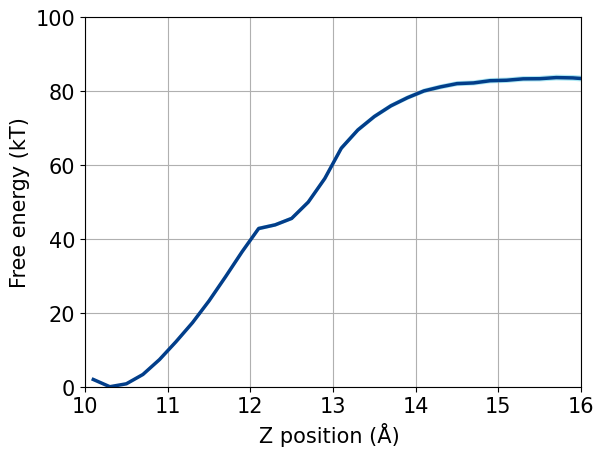

In [22]:
# Load data
data = np.loadtxt('./output-mbar/fes.dat')

bin_center_i = data[:, 0]
f_i = data[:, 1] - data[:, 1].min()
df_i= data[:, 2]

# Plot
fig, ax = plt.subplots()

ax.plot(bin_center_i, f_i, color="#023e8a", linewidth=2.5)
ax.fill_between(bin_center_i, f_i - df_i, f_i + df_i, color="#ade8f4")

ax.set_xlim(10, 16)
ax.set_ylim(0, 100)

ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_xlabel('Z position (Å) ',  fontsize=15)
ax.set_ylabel('Free energy (kT)', fontsize=15)
plt.grid()

os.makedirs('./assets/figures', exist_ok=True)
plt.savefig('./assets/figures/mbar_free_energy.png', bbox_inches='tight')
plt.savefig('./assets/figures/mbar_free_energy.pdf', bbox_inches='tight')